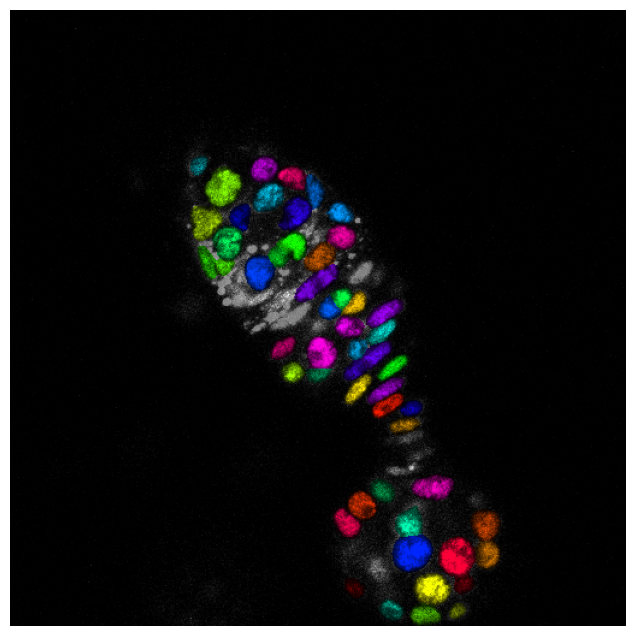

In [1]:
import numpy as np
from cellpose import plot, utils, io
import matplotlib.pyplot as plt

# Load segmentation data and image
dat = np.load('input_images/5_seg.npy', allow_pickle=True).item()
img = io.imread('input_images/5.tif')

# Create an overlay image with colored masks
mask_RGB = plot.mask_overlay(img, dat['masks'])

# Plot the image with the filled masks overlaid
plt.figure(figsize=(8, 8))
plt.imshow(mask_RGB)
plt.axis('off')
plt.show()


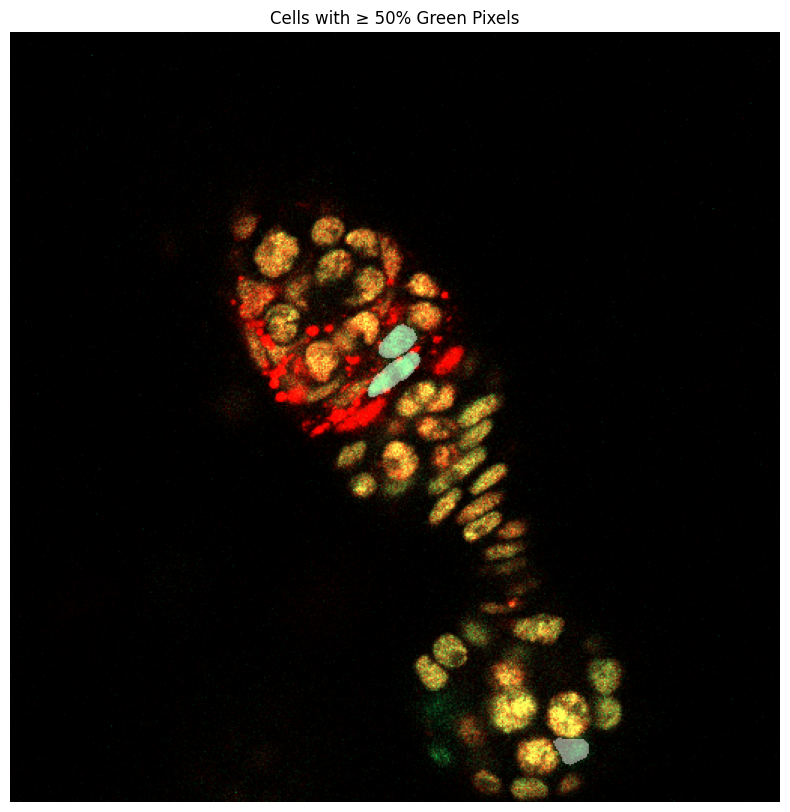

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Part 1: Build the dictionary
# -------------------------------

# Load segmentation data and image
dat = np.load('input_images/5_seg.npy', allow_pickle=True).item()
img = io.imread('input_images/5.tif')

# Ensure the image is in RGB (if grayscale, convert it)
if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
    img = np.stack([img.squeeze()] * 3, axis=-1)

masks = dat['masks']

# Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
# value -> average RGB value (will be used only for visualization, if desired)
mask_dict = {}
labels = np.unique(masks)
for label in labels:
    if label == 0:  # Skip background
        continue
    cell_mask = masks == label
    coords = np.argwhere(cell_mask)
    coords_tuple = tuple(map(tuple, coords))
    avg_rgb = np.mean(img[cell_mask], axis=0)
    mask_dict[coords_tuple] = avg_rgb

# -------------------------------
# Part 2: Filter cells using HSV thresholds
# -------------------------------

# Convert the image from RGB to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Define HSV boundaries for green (tweak these values as needed)
lower_green = np.array([45, 50, 50])
upper_green = np.array([75, 255, 255])

# Create a binary mask for green regions using cv2.inRange
hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)
# Note: pixels within the green range will have value 255 in hsv_green_mask

# Define the minimum ratio of green pixels for a cell to be considered "green"
green_pixel_ratio_threshold = 0.5  # 50% or more pixels must be green

# Filter the dictionary based on the percentage of green pixels in each cell
filtered_dict = {}
for coords, avg_rgb in mask_dict.items():
    coords_array = np.array(coords)  # shape (N, 2)
    # Extract the green mask values for the cell's pixels
    green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
    ratio_green = np.sum(green_vals == 255) / len(green_vals)
    if ratio_green >= green_pixel_ratio_threshold:
        filtered_dict[coords] = avg_rgb

# -------------------------------
# Part 3: Create an overlay mask and plot the filtered cells
# -------------------------------

# Create an empty boolean array to hold the overlay for filtered cells
overlay_mask = np.zeros(masks.shape, dtype=bool)
for coords in filtered_dict.keys():
    for (y, x) in coords:
        overlay_mask[y, x] = True

# Plot the original image and overlay the filtered cells in red
plt.figure(figsize=(10, 10))
plt.imshow(img)
masked_overlay = np.ma.masked_where(~overlay_mask, overlay_mask)
plt.imshow(masked_overlay, cmap='Reds', alpha=0.5)
plt.title(f'Cells with ≥ {int(green_pixel_ratio_threshold*100)}% Green Pixels')
plt.axis('off')
plt.show()

In [2]:
import os
import glob
import numpy as np
import cv2
from cellpose import models, io

# -------------------------------
# Cellpose Segmentation Setup with Gaussian Blurring
# -------------------------------
base_folder = 'A1-raw-data-2'  # Folder containing subfolders (e.g., t1, t2, ... t46)
model_type = 'cyto3'          # Use 'cyto' for whole cell segmentation or 'nuclei' for nuclear segmentation
use_gpu = True               # Set to False if a GPU is not available

# Instantiate the Cellpose model
model = models.Cellpose(model_type=model_type, gpu=use_gpu)

# Get all subfolders in the base folder
subfolders = [os.path.join(base_folder, d) for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))]

# Process each subfolder
for subfolder in subfolders:
    # Get list of all TIFF images in the subfolder
    image_files = glob.glob(os.path.join(subfolder, '*.tif'))
    
    for img_file in image_files:
        # Read the image using cellpose's io.imread (supports many image formats)
        img = io.imread(img_file)
    
        # Convert grayscale images to RGB if needed
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        elif img.ndim == 3 and img.shape[2] == 1:
            img = np.concatenate([img] * 3, axis=2)
    
        # Apply Gaussian blurring to the image before segmentation
        # Adjust the kernel size (5,5) and sigma value (0) as needed
        img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
        # For RGB images, using channels=[0,0] tells Cellpose to use the entire image
        channels = [0, 0]
    
        # Run the segmentation using Cellpose on the blurred image
        masks, flows, styles, diams = model.eval(img_blurred, channels=channels)
    
        # Save the segmentation results in a dictionary (the 'masks' key is used by the filtering cell)
        seg_data = {'masks': masks, 'flows': flows, 'styles': styles, 'diams': diams}
    
        # Construct the segmentation file name (e.g., 'image_seg.npy')
        base_name = os.path.splitext(os.path.basename(img_file))[0]
        seg_file = os.path.join(subfolder, base_name + '_seg.npy')
    
        np.save(seg_file, seg_data)
        print(f"Segmented {base_name} in folder {os.path.basename(subfolder)} and saved to {seg_file}.")


Segmented 15 in folder t16 and saved to A1-raw-data-2/t16/15_seg.npy.
Segmented 1 in folder t16 and saved to A1-raw-data-2/t16/1_seg.npy.
Segmented 5 in folder t16 and saved to A1-raw-data-2/t16/5_seg.npy.
Segmented 6 in folder t16 and saved to A1-raw-data-2/t16/6_seg.npy.
Segmented 4 in folder t16 and saved to A1-raw-data-2/t16/4_seg.npy.
Segmented 9 in folder t16 and saved to A1-raw-data-2/t16/9_seg.npy.
Segmented 10 in folder t16 and saved to A1-raw-data-2/t16/10_seg.npy.
Segmented 8 in folder t16 and saved to A1-raw-data-2/t16/8_seg.npy.
Segmented 14 in folder t16 and saved to A1-raw-data-2/t16/14_seg.npy.
Segmented 3 in folder t16 and saved to A1-raw-data-2/t16/3_seg.npy.
Segmented 12 in folder t16 and saved to A1-raw-data-2/t16/12_seg.npy.
Segmented 11 in folder t16 and saved to A1-raw-data-2/t16/11_seg.npy.
Segmented 13 in folder t16 and saved to A1-raw-data-2/t16/13_seg.npy.
Segmented 7 in folder t16 and saved to A1-raw-data-2/t16/7_seg.npy.
Segmented 2 in folder t16 and saved 

Segmented 5 in folder t13 and saved to A1-raw-data-2/t13/5_seg.npy.
Segmented 6 in folder t13 and saved to A1-raw-data-2/t13/6_seg.npy.
Segmented 4 in folder t13 and saved to A1-raw-data-2/t13/4_seg.npy.
Segmented 9 in folder t13 and saved to A1-raw-data-2/t13/9_seg.npy.
Segmented 10 in folder t13 and saved to A1-raw-data-2/t13/10_seg.npy.
Segmented 8 in folder t13 and saved to A1-raw-data-2/t13/8_seg.npy.
Segmented 14 in folder t13 and saved to A1-raw-data-2/t13/14_seg.npy.
Segmented 3 in folder t13 and saved to A1-raw-data-2/t13/3_seg.npy.
Segmented 12 in folder t13 and saved to A1-raw-data-2/t13/12_seg.npy.
Segmented 11 in folder t13 and saved to A1-raw-data-2/t13/11_seg.npy.
Segmented 13 in folder t13 and saved to A1-raw-data-2/t13/13_seg.npy.
Segmented 7 in folder t13 and saved to A1-raw-data-2/t13/7_seg.npy.
Segmented 2 in folder t13 and saved to A1-raw-data-2/t13/2_seg.npy.
Segmented 15 in folder t25 and saved to A1-raw-data-2/t25/15_seg.npy.
Segmented 1 in folder t25 and saved 

Segmented 9 in folder t46 and saved to A1-raw-data-2/t46/9_seg.npy.
Segmented 10 in folder t46 and saved to A1-raw-data-2/t46/10_seg.npy.
Segmented 8 in folder t46 and saved to A1-raw-data-2/t46/8_seg.npy.
Segmented 14 in folder t46 and saved to A1-raw-data-2/t46/14_seg.npy.
Segmented 3 in folder t46 and saved to A1-raw-data-2/t46/3_seg.npy.
Segmented 12 in folder t46 and saved to A1-raw-data-2/t46/12_seg.npy.
Segmented 11 in folder t46 and saved to A1-raw-data-2/t46/11_seg.npy.
Segmented 13 in folder t46 and saved to A1-raw-data-2/t46/13_seg.npy.
Segmented 7 in folder t46 and saved to A1-raw-data-2/t46/7_seg.npy.
Segmented 2 in folder t46 and saved to A1-raw-data-2/t46/2_seg.npy.
Segmented 15 in folder t18 and saved to A1-raw-data-2/t18/15_seg.npy.
Segmented 1 in folder t18 and saved to A1-raw-data-2/t18/1_seg.npy.
Segmented 5 in folder t18 and saved to A1-raw-data-2/t18/5_seg.npy.
Segmented 6 in folder t18 and saved to A1-raw-data-2/t18/6_seg.npy.
Segmented 4 in folder t18 and saved 

Segmented 8 in folder t38 and saved to A1-raw-data-2/t38/8_seg.npy.
Segmented 14 in folder t38 and saved to A1-raw-data-2/t38/14_seg.npy.
Segmented 3 in folder t38 and saved to A1-raw-data-2/t38/3_seg.npy.
Segmented 12 in folder t38 and saved to A1-raw-data-2/t38/12_seg.npy.
Segmented 11 in folder t38 and saved to A1-raw-data-2/t38/11_seg.npy.
Segmented 13 in folder t38 and saved to A1-raw-data-2/t38/13_seg.npy.
Segmented 7 in folder t38 and saved to A1-raw-data-2/t38/7_seg.npy.
Segmented 2 in folder t38 and saved to A1-raw-data-2/t38/2_seg.npy.
Segmented 15 in folder t15 and saved to A1-raw-data-2/t15/15_seg.npy.
Segmented 1 in folder t15 and saved to A1-raw-data-2/t15/1_seg.npy.
Segmented 5 in folder t15 and saved to A1-raw-data-2/t15/5_seg.npy.
Segmented 6 in folder t15 and saved to A1-raw-data-2/t15/6_seg.npy.
Segmented 4 in folder t15 and saved to A1-raw-data-2/t15/4_seg.npy.
Segmented 9 in folder t15 and saved to A1-raw-data-2/t15/9_seg.npy.
Segmented 10 in folder t15 and saved t

Segmented 14 in folder t45 and saved to A1-raw-data-2/t45/14_seg.npy.
Segmented 3 in folder t45 and saved to A1-raw-data-2/t45/3_seg.npy.
Segmented 12 in folder t45 and saved to A1-raw-data-2/t45/12_seg.npy.
Segmented 11 in folder t45 and saved to A1-raw-data-2/t45/11_seg.npy.
Segmented 13 in folder t45 and saved to A1-raw-data-2/t45/13_seg.npy.
Segmented 7 in folder t45 and saved to A1-raw-data-2/t45/7_seg.npy.
Segmented 2 in folder t45 and saved to A1-raw-data-2/t45/2_seg.npy.
Segmented 15 in folder t11 and saved to A1-raw-data-2/t11/15_seg.npy.
Segmented 1 in folder t11 and saved to A1-raw-data-2/t11/1_seg.npy.
Segmented 5 in folder t11 and saved to A1-raw-data-2/t11/5_seg.npy.
Segmented 6 in folder t11 and saved to A1-raw-data-2/t11/6_seg.npy.
Segmented 4 in folder t11 and saved to A1-raw-data-2/t11/4_seg.npy.
Segmented 9 in folder t11 and saved to A1-raw-data-2/t11/9_seg.npy.
Segmented 10 in folder t11 and saved to A1-raw-data-2/t11/10_seg.npy.
Segmented 8 in folder t11 and saved 

no seeds found in get_masks_torch - no masks found.


Segmented 2 in folder t11 and saved to A1-raw-data-2/t11/2_seg.npy.
Segmented 15 in folder t4 and saved to A1-raw-data-2/t4/15_seg.npy.
Segmented 1 in folder t4 and saved to A1-raw-data-2/t4/1_seg.npy.
Segmented 5 in folder t4 and saved to A1-raw-data-2/t4/5_seg.npy.
Segmented 6 in folder t4 and saved to A1-raw-data-2/t4/6_seg.npy.
Segmented 4 in folder t4 and saved to A1-raw-data-2/t4/4_seg.npy.
Segmented 9 in folder t4 and saved to A1-raw-data-2/t4/9_seg.npy.
Segmented 10 in folder t4 and saved to A1-raw-data-2/t4/10_seg.npy.
Segmented 8 in folder t4 and saved to A1-raw-data-2/t4/8_seg.npy.
Segmented 14 in folder t4 and saved to A1-raw-data-2/t4/14_seg.npy.
Segmented 3 in folder t4 and saved to A1-raw-data-2/t4/3_seg.npy.
Segmented 12 in folder t4 and saved to A1-raw-data-2/t4/12_seg.npy.
Segmented 11 in folder t4 and saved to A1-raw-data-2/t4/11_seg.npy.
Segmented 13 in folder t4 and saved to A1-raw-data-2/t4/13_seg.npy.
Segmented 7 in folder t4 and saved to A1-raw-data-2/t4/7_seg.n

Segmented 15 in folder t40 and saved to A1-raw-data-2/t40/15_seg.npy.
Segmented 1 in folder t40 and saved to A1-raw-data-2/t40/1_seg.npy.
Segmented 5 in folder t40 and saved to A1-raw-data-2/t40/5_seg.npy.
Segmented 6 in folder t40 and saved to A1-raw-data-2/t40/6_seg.npy.
Segmented 4 in folder t40 and saved to A1-raw-data-2/t40/4_seg.npy.
Segmented 9 in folder t40 and saved to A1-raw-data-2/t40/9_seg.npy.
Segmented 10 in folder t40 and saved to A1-raw-data-2/t40/10_seg.npy.
Segmented 8 in folder t40 and saved to A1-raw-data-2/t40/8_seg.npy.
Segmented 14 in folder t40 and saved to A1-raw-data-2/t40/14_seg.npy.
Segmented 3 in folder t40 and saved to A1-raw-data-2/t40/3_seg.npy.
Segmented 12 in folder t40 and saved to A1-raw-data-2/t40/12_seg.npy.
Segmented 11 in folder t40 and saved to A1-raw-data-2/t40/11_seg.npy.
Segmented 13 in folder t40 and saved to A1-raw-data-2/t40/13_seg.npy.
Segmented 7 in folder t40 and saved to A1-raw-data-2/t40/7_seg.npy.
Segmented 2 in folder t40 and saved 

In [6]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Configuration and Setup
# -------------------------------
base_input_folder = 'A1-raw-data-2'  # Base folder containing subfolders with images and segmentation files
output_folder_images = 'output-images-2'       # For saving overlay images
output_folder_outlines = 'output-outlines-2'    # For saving cell outlines

# Create output directories if they don't exist
os.makedirs(output_folder_images, exist_ok=True)
os.makedirs(output_folder_outlines, exist_ok=True)

# Recursively find all segmentation files (assumed to end with '_seg.npy')
segmentation_files = glob.glob(os.path.join(base_input_folder, '**', '*_seg.npy'), recursive=True)

# Define HSV thresholds and green pixel ratio threshold
lower_green = np.array([40, 45, 45])
upper_green = np.array([80, 255, 255])
green_pixel_ratio_threshold = 0.50  # 50% or more pixels must be green

# -------------------------------
# Process each file pair in the folder tree
# -------------------------------
for seg_file in segmentation_files:
    # Determine the base name (e.g., "image_seg.npy" -> "image")
    base_name = os.path.basename(seg_file).replace('_seg.npy', '')
    
    # The corresponding image is assumed to be in the same folder with a .tif extension
    img_file = os.path.join(os.path.dirname(seg_file), base_name + '.tif')
    
    # Check if the corresponding image file exists
    if not os.path.exists(img_file):
        print(f"Image file {img_file} not found for segmentation file {seg_file}. Skipping.")
        continue

    # Determine subfolder relative to the base_input_folder for output organization
    subfolder = os.path.relpath(os.path.dirname(seg_file), base_input_folder)
    out_img_folder = os.path.join(output_folder_images, subfolder)
    out_outline_folder = os.path.join(output_folder_outlines, subfolder)
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_outline_folder, exist_ok=True)
    
    print(f"Processing {base_name} in folder {subfolder}...")

    # -------------------------------
    # Part 1: Load data and build the mask dictionary
    # -------------------------------
    dat = np.load(seg_file, allow_pickle=True).item()
    img = io.imread(img_file)

    # Ensure the image is in RGB (if grayscale, convert it)
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        img = np.stack([img.squeeze()] * 3, axis=-1)

    masks = dat['masks']

    # Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
    # value -> average RGB value (for visualization if desired)
    mask_dict = {}
    labels = np.unique(masks)
    for label in labels:
        if label == 0:  # Skip background
            continue
        cell_mask = masks == label
        coords = np.argwhere(cell_mask)
        coords_tuple = tuple(map(tuple, coords))
        avg_rgb = np.mean(img[cell_mask], axis=0)
        mask_dict[coords_tuple] = avg_rgb

    # -------------------------------
    # Part 2: Filter cells using HSV thresholds
    # -------------------------------
    # Convert the image from RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    # Create a binary mask for green regions
    hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)

    filtered_dict = {}
    for coords, avg_rgb in mask_dict.items():
        coords_array = np.array(coords)  # shape (N, 2)
        # Extract the green mask values for the cell's pixels
        green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
        ratio_green = np.sum(green_vals == 255) / len(green_vals)
        #if ratio_green >= green_pixel_ratio_threshold:
        filtered_dict[coords] = avg_rgb

    # -------------------------------
    # Part 3: Create an overlay mask and save the overlay image
    # -------------------------------
    overlay_mask = np.zeros(masks.shape, dtype=bool)
    for coords in filtered_dict.keys():
        for (y, x) in coords:
            overlay_mask[y, x] = True

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    masked_overlay = np.ma.masked_where(~overlay_mask, overlay_mask)
    plt.imshow(masked_overlay, cmap='Reds', alpha=0.5)
    plt.title(f'Cells with ≥ {int(green_pixel_ratio_threshold*100)}% Green Pixels')
    plt.axis('off')

    # Save the overlay image to the output folder (preserving subfolder structure)
    output_overlay_file = os.path.join(out_img_folder, base_name + '_overlay.png')
    plt.savefig(output_overlay_file, bbox_inches='tight')
    plt.close()

    # -------------------------------
    # Part 4: Extract cell outlines and write to file
    # -------------------------------
    outline_file = os.path.join(out_outline_folder, base_name + '_outlines.txt')
    with open(outline_file, "w") as f:
        for coords in filtered_dict.keys():
            # Create a binary image for this cell mask
            cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
            coords_np = np.array(coords)
            cell_mask_img[coords_np[:, 0], coords_np[:, 1]] = 255

            # Find contours; using RETR_EXTERNAL to get only the outer boundary
            contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) == 0:
                continue

            # Choose the largest contour (in case there are multiple)
            largest_contour = max(contours, key=cv2.contourArea)
            largest_contour = largest_contour.squeeze()
            # Ensure the contour is 2D (in case it's only a single point)
            if largest_contour.ndim == 1:
                largest_contour = np.expand_dims(largest_contour, axis=0)

            # Format the contour as "x,y,x,y,..." (note: OpenCV contours are in (x,y) order)
            coord_pairs = [f"{pt[0]},{pt[1]}" for pt in largest_contour]
            outline_str = ",".join(coord_pairs)
            f.write(outline_str + "\n")

    print(f"Finished processing {base_name} in folder {subfolder}.")
    print(f" - Overlay saved to: {output_overlay_file}")
    print(f" - Outlines saved to: {outline_file}")


Processing 13 in folder t16...
Finished processing 13 in folder t16.
 - Overlay saved to: output-images-2/t16/13_overlay.png
 - Outlines saved to: output-outlines-2/t16/13_outlines.txt
Processing 9 in folder t16...
Finished processing 9 in folder t16.
 - Overlay saved to: output-images-2/t16/9_overlay.png
 - Outlines saved to: output-outlines-2/t16/9_outlines.txt
Processing 1 in folder t16...
Finished processing 1 in folder t16.
 - Overlay saved to: output-images-2/t16/1_overlay.png
 - Outlines saved to: output-outlines-2/t16/1_outlines.txt
Processing 12 in folder t16...
Finished processing 12 in folder t16.
 - Overlay saved to: output-images-2/t16/12_overlay.png
 - Outlines saved to: output-outlines-2/t16/12_outlines.txt
Processing 15 in folder t16...
Finished processing 15 in folder t16.
 - Overlay saved to: output-images-2/t16/15_overlay.png
 - Outlines saved to: output-outlines-2/t16/15_outlines.txt
Processing 5 in folder t16...
Finished processing 5 in folder t16.
 - Overlay saved

Finished processing 13 in folder t20.
 - Overlay saved to: output-images-2/t20/13_overlay.png
 - Outlines saved to: output-outlines-2/t20/13_outlines.txt
Processing 9 in folder t20...
Finished processing 9 in folder t20.
 - Overlay saved to: output-images-2/t20/9_overlay.png
 - Outlines saved to: output-outlines-2/t20/9_outlines.txt
Processing 1 in folder t20...
Finished processing 1 in folder t20.
 - Overlay saved to: output-images-2/t20/1_overlay.png
 - Outlines saved to: output-outlines-2/t20/1_outlines.txt
Processing 12 in folder t20...
Finished processing 12 in folder t20.
 - Overlay saved to: output-images-2/t20/12_overlay.png
 - Outlines saved to: output-outlines-2/t20/12_outlines.txt
Processing 15 in folder t20...
Finished processing 15 in folder t20.
 - Overlay saved to: output-images-2/t20/15_overlay.png
 - Outlines saved to: output-outlines-2/t20/15_outlines.txt
Processing 5 in folder t20...
Finished processing 5 in folder t20.
 - Overlay saved to: output-images-2/t20/5_over

Finished processing 13 in folder t42.
 - Overlay saved to: output-images-2/t42/13_overlay.png
 - Outlines saved to: output-outlines-2/t42/13_outlines.txt
Processing 9 in folder t42...
Finished processing 9 in folder t42.
 - Overlay saved to: output-images-2/t42/9_overlay.png
 - Outlines saved to: output-outlines-2/t42/9_outlines.txt
Processing 1 in folder t42...
Finished processing 1 in folder t42.
 - Overlay saved to: output-images-2/t42/1_overlay.png
 - Outlines saved to: output-outlines-2/t42/1_outlines.txt
Processing 12 in folder t42...
Finished processing 12 in folder t42.
 - Overlay saved to: output-images-2/t42/12_overlay.png
 - Outlines saved to: output-outlines-2/t42/12_outlines.txt
Processing 15 in folder t42...
Finished processing 15 in folder t42.
 - Overlay saved to: output-images-2/t42/15_overlay.png
 - Outlines saved to: output-outlines-2/t42/15_outlines.txt
Processing 5 in folder t42...
Finished processing 5 in folder t42.
 - Overlay saved to: output-images-2/t42/5_over

Finished processing 13 in folder t25.
 - Overlay saved to: output-images-2/t25/13_overlay.png
 - Outlines saved to: output-outlines-2/t25/13_outlines.txt
Processing 9 in folder t25...
Finished processing 9 in folder t25.
 - Overlay saved to: output-images-2/t25/9_overlay.png
 - Outlines saved to: output-outlines-2/t25/9_outlines.txt
Processing 1 in folder t25...
Finished processing 1 in folder t25.
 - Overlay saved to: output-images-2/t25/1_overlay.png
 - Outlines saved to: output-outlines-2/t25/1_outlines.txt
Processing 12 in folder t25...
Finished processing 12 in folder t25.
 - Overlay saved to: output-images-2/t25/12_overlay.png
 - Outlines saved to: output-outlines-2/t25/12_outlines.txt
Processing 15 in folder t25...
Finished processing 15 in folder t25.
 - Overlay saved to: output-images-2/t25/15_overlay.png
 - Outlines saved to: output-outlines-2/t25/15_outlines.txt
Processing 5 in folder t25...
Finished processing 5 in folder t25.
 - Overlay saved to: output-images-2/t25/5_over

Finished processing 13 in folder t3.
 - Overlay saved to: output-images-2/t3/13_overlay.png
 - Outlines saved to: output-outlines-2/t3/13_outlines.txt
Processing 9 in folder t3...
Finished processing 9 in folder t3.
 - Overlay saved to: output-images-2/t3/9_overlay.png
 - Outlines saved to: output-outlines-2/t3/9_outlines.txt
Processing 1 in folder t3...
Finished processing 1 in folder t3.
 - Overlay saved to: output-images-2/t3/1_overlay.png
 - Outlines saved to: output-outlines-2/t3/1_outlines.txt
Processing 12 in folder t3...
Finished processing 12 in folder t3.
 - Overlay saved to: output-images-2/t3/12_overlay.png
 - Outlines saved to: output-outlines-2/t3/12_outlines.txt
Processing 15 in folder t3...
Finished processing 15 in folder t3.
 - Overlay saved to: output-images-2/t3/15_overlay.png
 - Outlines saved to: output-outlines-2/t3/15_outlines.txt
Processing 5 in folder t3...
Finished processing 5 in folder t3.
 - Overlay saved to: output-images-2/t3/5_overlay.png
 - Outlines sa

...

Finished processing 10 in folder t11.
 - Overlay saved to: output-images-2/t11/10_overlay.png
 - Outlines saved to: output-outlines-2/t11/10_outlines.txt
Processing 2 in folder t11...
Finished processing 2 in folder t11.
 - Overlay saved to: output-images-2/t11/2_overlay.png
 - Outlines saved to: output-outlines-2/t11/2_outlines.txt
Processing 4 in folder t11...
Finished processing 4 in folder t11.
 - Overlay saved to: output-images-2/t11/4_overlay.png
 - Outlines saved to: output-outlines-2/t11/4_outlines.txt
Processing 8 in folder t11...
Finished processing 8 in folder t11.
 - Overlay saved to: output-images-2/t11/8_overlay.png
 - Outlines saved to: output-outlines-2/t11/8_outlines.txt
Processing 6 in folder t11...
Finished processing 6 in folder t11.
 - Overlay saved to: output-images-2/t11/6_overlay.png
 - Outlines saved to: output-outlines-2/t11/6_outlines.txt
Processing 14 in folder t11...
Finished processing 14 in folder t11.
 - Overlay saved to: output-images-2/t11/14_overlay.p

Finished processing 2 in folder t30.
 - Overlay saved to: output-images-2/t30/2_overlay.png
 - Outlines saved to: output-outlines-2/t30/2_outlines.txt
Processing 4 in folder t30...
Finished processing 4 in folder t30.
 - Overlay saved to: output-images-2/t30/4_overlay.png
 - Outlines saved to: output-outlines-2/t30/4_outlines.txt
Processing 8 in folder t30...
Finished processing 8 in folder t30.
 - Overlay saved to: output-images-2/t30/8_overlay.png
 - Outlines saved to: output-outlines-2/t30/8_outlines.txt
Processing 6 in folder t30...
Finished processing 6 in folder t30.
 - Overlay saved to: output-images-2/t30/6_overlay.png
 - Outlines saved to: output-outlines-2/t30/6_outlines.txt
Processing 14 in folder t30...
Finished processing 14 in folder t30.
 - Overlay saved to: output-images-2/t30/14_overlay.png
 - Outlines saved to: output-outlines-2/t30/14_outlines.txt
Processing 3 in folder t30...
Finished processing 3 in folder t30.
 - Overlay saved to: output-images-2/t30/3_overlay.png

Finished processing 4 in folder t35.
 - Overlay saved to: output-images-2/t35/4_overlay.png
 - Outlines saved to: output-outlines-2/t35/4_outlines.txt
Processing 8 in folder t35...
Finished processing 8 in folder t35.
 - Overlay saved to: output-images-2/t35/8_overlay.png
 - Outlines saved to: output-outlines-2/t35/8_outlines.txt
Processing 6 in folder t35...
Finished processing 6 in folder t35.
 - Overlay saved to: output-images-2/t35/6_overlay.png
 - Outlines saved to: output-outlines-2/t35/6_outlines.txt
Processing 14 in folder t35...
Finished processing 14 in folder t35.
 - Overlay saved to: output-images-2/t35/14_overlay.png
 - Outlines saved to: output-outlines-2/t35/14_outlines.txt
Processing 3 in folder t35...
Finished processing 3 in folder t35.
 - Overlay saved to: output-images-2/t35/3_overlay.png
 - Outlines saved to: output-outlines-2/t35/3_outlines.txt
Processing 7 in folder t35...
Finished processing 7 in folder t35.
 - Overlay saved to: output-images-2/t35/7_overlay.png

Finished processing 4 in folder t40.
 - Overlay saved to: output-images-2/t40/4_overlay.png
 - Outlines saved to: output-outlines-2/t40/4_outlines.txt
Processing 8 in folder t40...
Finished processing 8 in folder t40.
 - Overlay saved to: output-images-2/t40/8_overlay.png
 - Outlines saved to: output-outlines-2/t40/8_outlines.txt
Processing 6 in folder t40...
Finished processing 6 in folder t40.
 - Overlay saved to: output-images-2/t40/6_overlay.png
 - Outlines saved to: output-outlines-2/t40/6_outlines.txt
Processing 14 in folder t40...
Finished processing 14 in folder t40.
 - Overlay saved to: output-images-2/t40/14_overlay.png
 - Outlines saved to: output-outlines-2/t40/14_outlines.txt
Processing 3 in folder t40...
Finished processing 3 in folder t40.
 - Overlay saved to: output-images-2/t40/3_overlay.png
 - Outlines saved to: output-outlines-2/t40/3_outlines.txt
Processing 7 in folder t40...
Finished processing 7 in folder t40.
 - Overlay saved to: output-images-2/t40/7_overlay.png

Finished processing 8 in folder t9.
 - Overlay saved to: output-images-2/t9/8_overlay.png
 - Outlines saved to: output-outlines-2/t9/8_outlines.txt
Processing 6 in folder t9...
Finished processing 6 in folder t9.
 - Overlay saved to: output-images-2/t9/6_overlay.png
 - Outlines saved to: output-outlines-2/t9/6_outlines.txt
Processing 14 in folder t9...
Finished processing 14 in folder t9.
 - Overlay saved to: output-images-2/t9/14_overlay.png
 - Outlines saved to: output-outlines-2/t9/14_outlines.txt
Processing 3 in folder t9...
Finished processing 3 in folder t9.
 - Overlay saved to: output-images-2/t9/3_overlay.png
 - Outlines saved to: output-outlines-2/t9/3_outlines.txt
Processing 7 in folder t9...
Finished processing 7 in folder t9.
 - Overlay saved to: output-images-2/t9/7_overlay.png
 - Outlines saved to: output-outlines-2/t9/7_outlines.txt
Processing 11 in folder t9...
Finished processing 11 in folder t9.
 - Overlay saved to: output-images-2/t9/11_overlay.png
 - Outlines saved 

In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Configuration and Setup
# -------------------------------
base_input_folder = 'A1-raw-data-2'  # Base folder containing subfolders with images and segmentation files
output_folder_images = 'output-images-5'       # For saving overlay images
output_folder_outlines = 'output-outlines-5'    # For saving cell outlines

# Create output directories if they don't exist
os.makedirs(output_folder_images, exist_ok=True)
os.makedirs(output_folder_outlines, exist_ok=True)

# Recursively find all segmentation files (assumed to end with '_seg.npy')
segmentation_files = glob.glob(os.path.join(base_input_folder, '**', '*_seg.npy'), recursive=True)

# Define HSV thresholds and green pixel ratio threshold
lower_green = np.array([40, 45, 45])
upper_green = np.array([80, 255, 255])
green_pixel_ratio_threshold = 0.50  # 50% or more pixels must be green

# -------------------------------
# Process each file pair in the folder tree
# -------------------------------
for seg_file in segmentation_files:
    # Determine the base name (e.g., "image_seg.npy" -> "image")
    base_name = os.path.basename(seg_file).replace('_seg.npy', '')
    
    # The corresponding image is assumed to be in the same folder with a .tif extension
    img_file = os.path.join(os.path.dirname(seg_file), base_name + '.tif')
    
    # Check if the corresponding image file exists
    if not os.path.exists(img_file):
        print(f"Image file {img_file} not found for segmentation file {seg_file}. Skipping.")
        continue

    # Determine subfolder relative to the base_input_folder for output organization
    subfolder = os.path.relpath(os.path.dirname(seg_file), base_input_folder)
    out_img_folder = os.path.join(output_folder_images, subfolder)
    out_outline_folder = os.path.join(output_folder_outlines, subfolder)
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_outline_folder, exist_ok=True)
    
    print(f"Processing {base_name} in folder {subfolder}...")

    # -------------------------------
    # Part 1: Load data and build the mask dictionary
    # -------------------------------
    dat = np.load(seg_file, allow_pickle=True).item()
    img = io.imread(img_file)

    # Ensure the image is in RGB (if grayscale, convert it)
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        img = np.stack([img.squeeze()] * 3, axis=-1)

    masks = dat['masks']

    # Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
    # value -> average RGB value (for visualization if desired)
    mask_dict = {}
    labels = np.unique(masks)
    for label in labels:
        if label == 0:  # Skip background
            continue
        cell_mask = masks == label
        coords = np.argwhere(cell_mask)
        coords_tuple = tuple(map(tuple, coords))
        avg_rgb = np.mean(img[cell_mask], axis=0)
        mask_dict[coords_tuple] = avg_rgb

    # -------------------------------
    # Part 2: Filter cells using HSV thresholds
    # -------------------------------
    # Convert the image from RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    # Create a binary mask for green regions
    hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)

    filtered_dict = {}
    for coords, avg_rgb in mask_dict.items():
        coords_array = np.array(coords)  # shape (N, 2)
        # Extract the green mask values for the cell's pixels
        green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
        ratio_green = np.sum(green_vals == 255) / len(green_vals)
        if ratio_green >= green_pixel_ratio_threshold:
            filtered_dict[coords] = avg_rgb

    # -------------------------------
    # Part 3: Create a black background with just the green cells and save the image
    # -------------------------------
    # Create a black background image (all zeros)
    green_cells_image = np.zeros(img.shape, dtype=np.uint8)
    
    # Set the green cells to green color (0, 255, 0) on the black background
    for coords in filtered_dict.keys():
        coords_array = np.array(coords)
        # Use a pure green color for all cells
        green_cells_image[coords_array[:, 0], coords_array[:, 1]] = [0, 255, 0]  # RGB for green

    # Save the green cells image to the output folder (preserving subfolder structure)
    output_green_cells_file = os.path.join(out_img_folder, base_name + '_green_cells.png')
    
    # Setup the figure with tight layout and no edge padding
    plt.figure(figsize=(10, 10))
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove internal padding
    plt.imshow(green_cells_image)
    plt.axis('off')  # Turn off axis
    
    # Save with tight bounding box, no padding, and black background
    plt.savefig(output_green_cells_file, 
                bbox_inches='tight',  # Remove any extra whitespace
                pad_inches=0,         # Remove all padding
                facecolor='black',    # Make figure background black
                dpi=300)              # Higher DPI for better quality
    plt.close()

    # -------------------------------
    # Part 4: Extract cell outlines and write to file
    # -------------------------------
    outline_file = os.path.join(out_outline_folder, base_name + '_outlines.txt')
    with open(outline_file, "w") as f:
        for coords in filtered_dict.keys():
            # Create a binary image for this cell mask
            cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
            coords_np = np.array(coords)
            cell_mask_img[coords_np[:, 0], coords_np[:, 1]] = 255

            # Find contours; using RETR_EXTERNAL to get only the outer boundary
            contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) == 0:
                continue

            # Choose the largest contour (in case there are multiple)
            largest_contour = max(contours, key=cv2.contourArea)
            largest_contour = largest_contour.squeeze()
            # Ensure the contour is 2D (in case it's only a single point)
            if largest_contour.ndim == 1:
                largest_contour = np.expand_dims(largest_contour, axis=0)

            # Format the contour as "x,y,x,y,..." (note: OpenCV contours are in (x,y) order)
            coord_pairs = [f"{pt[0]},{pt[1]}" for pt in largest_contour]
            outline_str = ",".join(coord_pairs)
            f.write(outline_str + "\n")

    print(f"Finished processing {base_name} in folder {subfolder}.")
    print(f" - Green cells image saved to: {output_green_cells_file}")
    print(f" - Outlines saved to: {outline_file}")

Processing 13 in folder t16...
Finished processing 13 in folder t16.
 - Green cells image saved to: output-images-5/t16/13_green_cells.png
 - Outlines saved to: output-outlines-5/t16/13_outlines.txt
Processing 9 in folder t16...
Finished processing 9 in folder t16.
 - Green cells image saved to: output-images-5/t16/9_green_cells.png
 - Outlines saved to: output-outlines-5/t16/9_outlines.txt
Processing 1 in folder t16...
Finished processing 1 in folder t16.
 - Green cells image saved to: output-images-5/t16/1_green_cells.png
 - Outlines saved to: output-outlines-5/t16/1_outlines.txt
Processing 12 in folder t16...
Finished processing 12 in folder t16.
 - Green cells image saved to: output-images-5/t16/12_green_cells.png
 - Outlines saved to: output-outlines-5/t16/12_outlines.txt
Processing 15 in folder t16...
Finished processing 15 in folder t16.
 - Green cells image saved to: output-images-5/t16/15_green_cells.png
 - Outlines saved to: output-outlines-5/t16/15_outlines.txt
Processing 5 

In [9]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Configuration and Setup
# -------------------------------
base_input_folder = 'A1-raw-data-2'  # Base folder containing subfolders with images and segmentation files
output_folder_images = 'output-images-2'       # For saving overlay images
output_folder_outlines = 'output-outlines-2'    # For saving cell outlines
output_folder_masks = 'output-masks-2'          # For saving filtered mask files

# Create output directories if they don't exist
os.makedirs(output_folder_images, exist_ok=True)
os.makedirs(output_folder_outlines, exist_ok=True)
os.makedirs(output_folder_masks, exist_ok=True)

# Recursively find all segmentation files (assumed to end with '_seg.npy')
segmentation_files = glob.glob(os.path.join(base_input_folder, '**', '*_seg.npy'), recursive=True)

# Define HSV thresholds and green pixel ratio threshold
lower_green = np.array([40, 45, 45])
upper_green = np.array([80, 255, 255])
green_pixel_ratio_threshold = 0.50  # 50% or more pixels must be green

# -------------------------------
# Process each file pair in the folder tree
# -------------------------------
for seg_file in segmentation_files:
    # Determine the base name (e.g., "image_seg.npy" -> "image")
    base_name = os.path.basename(seg_file).replace('_seg.npy', '')
    
    # The corresponding image is assumed to be in the same folder with a .tif extension
    img_file = os.path.join(os.path.dirname(seg_file), base_name + '.tif')
    
    # Check if the corresponding image file exists
    if not os.path.exists(img_file):
        print(f"Image file {img_file} not found for segmentation file {seg_file}. Skipping.")
        continue

    # Determine subfolder relative to the base_input_folder for output organization
    subfolder = os.path.relpath(os.path.dirname(seg_file), base_input_folder)
    out_img_folder = os.path.join(output_folder_images, subfolder)
    out_outline_folder = os.path.join(output_folder_outlines, subfolder)
    out_mask_folder = os.path.join(output_folder_masks, subfolder)
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_outline_folder, exist_ok=True)
    os.makedirs(out_mask_folder, exist_ok=True)
    
    print(f"Processing {base_name} in folder {subfolder}...")

    # -------------------------------
    # Part 1: Load data and build the mask dictionary
    # -------------------------------
    dat = np.load(seg_file, allow_pickle=True).item()
    img = io.imread(img_file)

    # Ensure the image is in RGB (if grayscale, convert it)
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        img = np.stack([img.squeeze()] * 3, axis=-1)

    masks = dat['masks']

    # Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
    # value -> average RGB value (for visualization if desired)
    mask_dict = {}
    labels = np.unique(masks)
    for label in labels:
        if label == 0:  # Skip background
            continue
        cell_mask = masks == label
        coords = np.argwhere(cell_mask)
        coords_tuple = tuple(map(tuple, coords))
        avg_rgb = np.mean(img[cell_mask], axis=0)
        mask_dict[coords_tuple] = avg_rgb

    # -------------------------------
    # Part 2: Filter cells using HSV thresholds
    # -------------------------------
    # Convert the image from RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    # Create a binary mask for green regions
    hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)

    filtered_dict = {}
    filtered_labels = []  # Keep track of which cell labels pass the filter
    
    for coords, avg_rgb in mask_dict.items():
        coords_array = np.array(coords)  # shape (N, 2)
        # Extract the green mask values for the cell's pixels
        green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
        ratio_green = np.sum(green_vals == 255) / len(green_vals)
        
        # Find the original label for this cell
        y, x = coords_array[0]  # Get coordinates of first pixel
        label = masks[y, x]
        
        if ratio_green >= green_pixel_ratio_threshold:
            filtered_dict[coords] = avg_rgb
            filtered_labels.append(label)

    # -------------------------------
    # Part 3: Create an overlay mask and save the overlay image
    # -------------------------------
    overlay_mask = np.zeros(masks.shape, dtype=bool)
    for coords in filtered_dict.keys():
        for (y, x) in coords:
            overlay_mask[y, x] = True

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    masked_overlay = np.ma.masked_where(~overlay_mask, overlay_mask)
    plt.imshow(masked_overlay, cmap='Reds', alpha=0.5)
    plt.title(f'Cells with ≥ {int(green_pixel_ratio_threshold*100)}% Green Pixels')
    plt.axis('off')

    # Save the overlay image to the output folder (preserving subfolder structure)
    output_overlay_file = os.path.join(out_img_folder, base_name + '_overlay.png')
    plt.savefig(output_overlay_file, bbox_inches='tight')
    plt.close()

    # -------------------------------
    # Part 4: Extract cell outlines and write to file
    # -------------------------------
    outline_file = os.path.join(out_outline_folder, base_name + '_outlines.txt')
    with open(outline_file, "w") as f:
        for coords in filtered_dict.keys():
            # Create a binary image for this cell mask
            cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
            coords_np = np.array(coords)
            cell_mask_img[coords_np[:, 0], coords_np[:, 1]] = 255

            # Find contours; using RETR_EXTERNAL to get only the outer boundary
            contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) == 0:
                continue

            # Choose the largest contour (in case there are multiple)
            largest_contour = max(contours, key=cv2.contourArea)
            largest_contour = largest_contour.squeeze()
            # Ensure the contour is 2D (in case it's only a single point)
            if largest_contour.ndim == 1:
                largest_contour = np.expand_dims(largest_contour, axis=0)

            # Format the contour as "x,y,x,y,..." (note: OpenCV contours are in (x,y) order)
            coord_pairs = [f"{pt[0]},{pt[1]}" for pt in largest_contour]
            outline_str = ",".join(coord_pairs)
            f.write(outline_str + "\n")
    
    # -------------------------------
    # Part 5: Create and save filtered masks file
    # -------------------------------
    # Create a new masks array with only the filtered cells
    filtered_masks = np.zeros_like(masks)
    for label in filtered_labels:
        filtered_masks[masks == label] = label
    
    # Create a new dictionary with the filtered masks to save
    filtered_dat = dat.copy()  # Copy all original data
    filtered_dat['masks'] = filtered_masks  # Replace with filtered masks
    
    # Save the filtered masks to a new npy file
    output_mask_file = os.path.join(out_mask_folder, base_name + '_filtered_seg.npy')
    np.save(output_mask_file, filtered_dat)

    print(f"Finished processing {base_name} in folder {subfolder}.")
    print(f" - Overlay saved to: {output_overlay_file}")
    print(f" - Outlines saved to: {outline_file}")
    print(f" - Filtered masks saved to: {output_mask_file}")

Processing 13 in folder t16...
Finished processing 13 in folder t16.
 - Overlay saved to: output-images-2/t16/13_overlay.png
 - Outlines saved to: output-outlines-2/t16/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/13_filtered_seg.npy
Processing 9 in folder t16...
Finished processing 9 in folder t16.
 - Overlay saved to: output-images-2/t16/9_overlay.png
 - Outlines saved to: output-outlines-2/t16/9_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/9_filtered_seg.npy
Processing 1 in folder t16...
Finished processing 1 in folder t16.
 - Overlay saved to: output-images-2/t16/1_overlay.png
 - Outlines saved to: output-outlines-2/t16/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/1_filtered_seg.npy
Processing 12 in folder t16...
Finished processing 12 in folder t16.
 - Overlay saved to: output-images-2/t16/12_overlay.png
 - Outlines saved to: output-outlines-2/t16/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/12_filtered_seg.npy
Pr

Finished processing 12 in folder t22.
 - Overlay saved to: output-images-2/t22/12_overlay.png
 - Outlines saved to: output-outlines-2/t22/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/12_filtered_seg.npy
Processing 15 in folder t22...
Finished processing 15 in folder t22.
 - Overlay saved to: output-images-2/t22/15_overlay.png
 - Outlines saved to: output-outlines-2/t22/15_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/15_filtered_seg.npy
Processing 5 in folder t22...
Finished processing 5 in folder t22.
 - Overlay saved to: output-images-2/t22/5_overlay.png
 - Outlines saved to: output-outlines-2/t22/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/5_filtered_seg.npy
Processing 10 in folder t22...
Finished processing 10 in folder t22.
 - Overlay saved to: output-images-2/t22/10_overlay.png
 - Outlines saved to: output-outlines-2/t22/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/10_filtered_seg.npy
Processing 2 in folder t22..

Finished processing 10 in folder t43.
 - Overlay saved to: output-images-2/t43/10_overlay.png
 - Outlines saved to: output-outlines-2/t43/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/10_filtered_seg.npy
Processing 2 in folder t43...
Finished processing 2 in folder t43.
 - Overlay saved to: output-images-2/t43/2_overlay.png
 - Outlines saved to: output-outlines-2/t43/2_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/2_filtered_seg.npy
Processing 4 in folder t43...
Finished processing 4 in folder t43.
 - Overlay saved to: output-images-2/t43/4_overlay.png
 - Outlines saved to: output-outlines-2/t43/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/4_filtered_seg.npy
Processing 8 in folder t43...
Finished processing 8 in folder t43.
 - Overlay saved to: output-images-2/t43/8_overlay.png
 - Outlines saved to: output-outlines-2/t43/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/8_filtered_seg.npy
Processing 6 in folder t43...
Finished

Finished processing 8 in folder t42.
 - Overlay saved to: output-images-2/t42/8_overlay.png
 - Outlines saved to: output-outlines-2/t42/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/8_filtered_seg.npy
Processing 6 in folder t42...
Finished processing 6 in folder t42.
 - Overlay saved to: output-images-2/t42/6_overlay.png
 - Outlines saved to: output-outlines-2/t42/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/6_filtered_seg.npy
Processing 14 in folder t42...
Finished processing 14 in folder t42.
 - Overlay saved to: output-images-2/t42/14_overlay.png
 - Outlines saved to: output-outlines-2/t42/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/14_filtered_seg.npy
Processing 3 in folder t42...
Finished processing 3 in folder t42.
 - Overlay saved to: output-images-2/t42/3_overlay.png
 - Outlines saved to: output-outlines-2/t42/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/3_filtered_seg.npy
Processing 7 in folder t42...
Finishe

Finished processing 3 in folder t13.
 - Overlay saved to: output-images-2/t13/3_overlay.png
 - Outlines saved to: output-outlines-2/t13/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/3_filtered_seg.npy
Processing 7 in folder t13...
Finished processing 7 in folder t13.
 - Overlay saved to: output-images-2/t13/7_overlay.png
 - Outlines saved to: output-outlines-2/t13/7_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/7_filtered_seg.npy
Processing 11 in folder t13...
Finished processing 11 in folder t13.
 - Overlay saved to: output-images-2/t13/11_overlay.png
 - Outlines saved to: output-outlines-2/t13/11_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/11_filtered_seg.npy
Processing 13 in folder t25...
Finished processing 13 in folder t25.
 - Overlay saved to: output-images-2/t25/13_overlay.png
 - Outlines saved to: output-outlines-2/t25/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t25/13_filtered_seg.npy
Processing 9 in folder t25...
Fi

...

Finished processing 6 in folder t26.
 - Overlay saved to: output-images-2/t26/6_overlay.png
 - Outlines saved to: output-outlines-2/t26/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/6_filtered_seg.npy
Processing 14 in folder t26...
Finished processing 14 in folder t26.
 - Overlay saved to: output-images-2/t26/14_overlay.png
 - Outlines saved to: output-outlines-2/t26/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/14_filtered_seg.npy
Processing 3 in folder t26...
Finished processing 3 in folder t26.
 - Overlay saved to: output-images-2/t26/3_overlay.png
 - Outlines saved to: output-outlines-2/t26/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/3_filtered_seg.npy
Processing 7 in folder t26...
Finished processing 7 in folder t26.
 - Overlay saved to: output-images-2/t26/7_overlay.png
 - Outlines saved to: output-outlines-2/t26/7_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/7_filtered_seg.npy
Processing 11 in folder t26...
Finish

Finished processing 11 in folder t6.
 - Overlay saved to: output-images-2/t6/11_overlay.png
 - Outlines saved to: output-outlines-2/t6/11_outlines.txt
 - Filtered masks saved to: output-masks-2/t6/11_filtered_seg.npy
Processing 13 in folder t12...
Finished processing 13 in folder t12.
 - Overlay saved to: output-images-2/t12/13_overlay.png
 - Outlines saved to: output-outlines-2/t12/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/13_filtered_seg.npy
Processing 9 in folder t12...
Finished processing 9 in folder t12.
 - Overlay saved to: output-images-2/t12/9_overlay.png
 - Outlines saved to: output-outlines-2/t12/9_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/9_filtered_seg.npy
Processing 1 in folder t12...
Finished processing 1 in folder t12.
 - Overlay saved to: output-images-2/t12/1_overlay.png
 - Outlines saved to: output-outlines-2/t12/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/1_filtered_seg.npy
Processing 12 in folder t12...
Finish

Finished processing 1 in folder t21.
 - Overlay saved to: output-images-2/t21/1_overlay.png
 - Outlines saved to: output-outlines-2/t21/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/1_filtered_seg.npy
Processing 12 in folder t21...
Finished processing 12 in folder t21.
 - Overlay saved to: output-images-2/t21/12_overlay.png
 - Outlines saved to: output-outlines-2/t21/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/12_filtered_seg.npy
Processing 15 in folder t21...
Finished processing 15 in folder t21.
 - Overlay saved to: output-images-2/t21/15_overlay.png
 - Outlines saved to: output-outlines-2/t21/15_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/15_filtered_seg.npy
Processing 5 in folder t21...
Finished processing 5 in folder t21.
 - Overlay saved to: output-images-2/t21/5_overlay.png
 - Outlines saved to: output-outlines-2/t21/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/5_filtered_seg.npy
Processing 10 in folder t21...
F

Finished processing 5 in folder t40.
 - Overlay saved to: output-images-2/t40/5_overlay.png
 - Outlines saved to: output-outlines-2/t40/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/5_filtered_seg.npy
Processing 10 in folder t40...
Finished processing 10 in folder t40.
 - Overlay saved to: output-images-2/t40/10_overlay.png
 - Outlines saved to: output-outlines-2/t40/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/10_filtered_seg.npy
Processing 2 in folder t40...
Finished processing 2 in folder t40.
 - Overlay saved to: output-images-2/t40/2_overlay.png
 - Outlines saved to: output-outlines-2/t40/2_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/2_filtered_seg.npy
Processing 4 in folder t40...
Finished processing 4 in folder t40.
 - Overlay saved to: output-images-2/t40/4_overlay.png
 - Outlines saved to: output-outlines-2/t40/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/4_filtered_seg.npy
Processing 8 in folder t40...
Finishe

Finished processing 4 in folder t37.
 - Overlay saved to: output-images-2/t37/4_overlay.png
 - Outlines saved to: output-outlines-2/t37/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/4_filtered_seg.npy
Processing 8 in folder t37...
Finished processing 8 in folder t37.
 - Overlay saved to: output-images-2/t37/8_overlay.png
 - Outlines saved to: output-outlines-2/t37/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/8_filtered_seg.npy
Processing 6 in folder t37...
Finished processing 6 in folder t37.
 - Overlay saved to: output-images-2/t37/6_overlay.png
 - Outlines saved to: output-outlines-2/t37/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/6_filtered_seg.npy
Processing 14 in folder t37...
Finished processing 14 in folder t37.
 - Overlay saved to: output-images-2/t37/14_overlay.png
 - Outlines saved to: output-outlines-2/t37/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/14_filtered_seg.npy
Processing 3 in folder t37...
Finishe

Keys in the NPY file: dict_keys(['masks', 'flows', 'styles', 'diams'])
Mask shape: (512, 512)
Number of unique cell IDs: 2


/tmp/ipykernel_15853/233889890.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet')


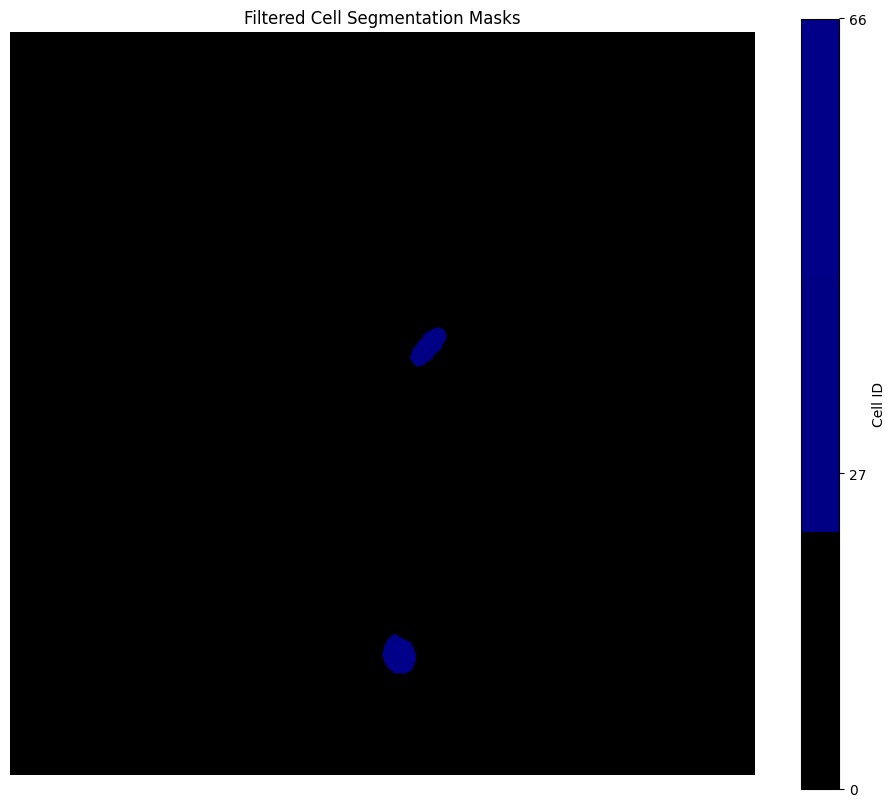

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import os

# Path to your filtered segmentation file
file_path = "output-masks-2/t1/7_filtered_seg.npy"

# Load the numpy file 
data = np.load(file_path, allow_pickle=True).item()

# Print what's inside the dictionary
print("Keys in the NPY file:", data.keys())

# Display the masks with a random colormap for better visualization
masks = data['masks']
print(f"Mask shape: {masks.shape}")
print(f"Number of unique cell IDs: {len(np.unique(masks)) - 1}")  # -1 to exclude background (0)

# Create a custom colormap for better visualization
# Make a random colormap with a black background (for ID=0)
n_labels = len(np.unique(masks))
cmap = plt.cm.get_cmap('jet')
# Create a colormap that has a black color for label 0 and random colors for others
colors_list = cmap(np.arange(n_labels))
colors_list[0] = [0, 0, 0, 1]  # black for background
custom_cmap = colors.ListedColormap(colors_list)

# Create the visualization
plt.figure(figsize=(12, 10))
plt.imshow(masks, cmap=custom_cmap)
plt.colorbar(ticks=np.unique(masks), label='Cell ID')
plt.title('Filtered Cell Segmentation Masks')
plt.axis('off')
plt.savefig(os.path.splitext(file_path)[0] + "_visualization.png", dpi=300, bbox_inches='tight')
plt.show()

# Optional: If you have the original image and want to create an overlay
# (assuming you have the original image in the same directory)
try:
    from cellpose import io
    original_img_path = file_path.replace('_filtered_seg.npy', '.tif')
    if os.path.exists(original_img_path):
        img = io.imread(original_img_path)
        
        # Create an overlay visualization
        plt.figure(figsize=(12, 10))
        plt.imshow(img)
        
        # Create a mask for overlay visualization
        mask_boundaries = np.zeros_like(masks, dtype=bool)
        for i in range(1, np.max(masks)+1):
            if i in np.unique(masks):
                cell = masks == i
                eroded = binary_erosion(cell, iterations=1)
                mask_boundaries[cell & ~eroded] = True
        
        masked_overlay = np.ma.masked_where(~mask_boundaries, mask_boundaries)
        plt.imshow(masked_overlay, cmap='spring', alpha=0.8)
        plt.title('Original Image with Cell Boundaries')
        plt.axis('off')
        plt.savefig(os.path.splitext(file_path)[0] + "_overlay.png", dpi=300, bbox_inches='tight')
        plt.show()
except:
    print("Could not create overlay. Make sure original image exists and cellpose is installed.")

In [17]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io, utils
import shutil

# -------------------------------
# Configuration and Setup
# -------------------------------
base_input_folder = 'A1-raw-data-2'  # Base folder containing subfolders with images and segmentation files
output_folder_images = 'output-images-2'       # For saving overlay images
output_folder_outlines = 'output-outlines-2'    # For saving cell outlines
output_folder_masks = 'output-masks-2'          # For saving filtered mask files

# Create output directories if they don't exist
os.makedirs(output_folder_images, exist_ok=True)
os.makedirs(output_folder_outlines, exist_ok=True)
os.makedirs(output_folder_masks, exist_ok=True)

# Recursively find all segmentation files (assumed to end with '_seg.npy')
segmentation_files = glob.glob(os.path.join(base_input_folder, '**', '*_seg.npy'), recursive=True)

# Define HSV thresholds and green pixel ratio threshold
lower_green = np.array([40, 45, 45])
upper_green = np.array([80, 255, 255])
green_pixel_ratio_threshold = 0.50  # 50% or more pixels must be green

# -------------------------------
# Process each file pair in the folder tree
# -------------------------------
for seg_file in segmentation_files:
    # Determine the base name (e.g., "image_seg.npy" -> "image")
    base_name = os.path.basename(seg_file).replace('_seg.npy', '')
    
    # The corresponding image is assumed to be in the same folder with a .tif extension
    img_file = os.path.join(os.path.dirname(seg_file), base_name + '.tif')
    
    # Check if the corresponding image file exists
    if not os.path.exists(img_file):
        print(f"Image file {img_file} not found for segmentation file {seg_file}. Skipping.")
        continue

    # Determine subfolder relative to the base_input_folder for output organization
    subfolder = os.path.relpath(os.path.dirname(seg_file), base_input_folder)
    out_img_folder = os.path.join(output_folder_images, subfolder)
    out_outline_folder = os.path.join(output_folder_outlines, subfolder)
    out_mask_folder = os.path.join(output_folder_masks, subfolder)
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_outline_folder, exist_ok=True)
    os.makedirs(out_mask_folder, exist_ok=True)
    
    print(f"Processing {base_name} in folder {subfolder}...")

    # -------------------------------
    # Part 1: Load data and build the mask dictionary
    # -------------------------------
    # First, create a copy of the original file to preserve all metadata and format
    output_mask_file = os.path.join(out_mask_folder, base_name + '_filtered_seg.npy')
    shutil.copy2(seg_file, output_mask_file)
    
    # Now load the original data
    dat = np.load(seg_file, allow_pickle=True).item()
    img = io.imread(img_file)

    # Ensure the image is in RGB (if grayscale, convert it)
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        img = np.stack([img.squeeze()] * 3, axis=-1)

    masks = dat['masks']

    # Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
    # value -> average RGB value (for visualization if desired)
    mask_dict = {}
    labels = np.unique(masks)
    for label in labels:
        if label == 0:  # Skip background
            continue
        cell_mask = masks == label
        coords = np.argwhere(cell_mask)
        coords_tuple = tuple(map(tuple, coords))
        avg_rgb = np.mean(img[cell_mask], axis=0)
        mask_dict[coords_tuple] = avg_rgb

    # -------------------------------
    # Part 2: Filter cells using HSV thresholds
    # -------------------------------
    # Convert the image from RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    # Create a binary mask for green regions
    hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)

    filtered_dict = {}
    filtered_labels = []  # Keep track of which cell labels pass the filter
    
    for coords, avg_rgb in mask_dict.items():
        coords_array = np.array(coords)  # shape (N, 2)
        # Extract the green mask values for the cell's pixels
        green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
        ratio_green = np.sum(green_vals == 255) / len(green_vals)
        
        # Find the original label for this cell
        y, x = coords_array[0]  # Get coordinates of first pixel
        label = masks[y, x]
        
        if ratio_green >= green_pixel_ratio_threshold:
            filtered_dict[coords] = avg_rgb
            filtered_labels.append(label)

    # -------------------------------
    # Part 3: Create an overlay mask and save the overlay image
    # -------------------------------
    overlay_mask = np.zeros(masks.shape, dtype=bool)
    for coords in filtered_dict.keys():
        for (y, x) in coords:
            overlay_mask[y, x] = True

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    masked_overlay = np.ma.masked_where(~overlay_mask, overlay_mask)
    plt.imshow(masked_overlay, cmap='Reds', alpha=0.5)
    plt.title(f'Cells with ≥ {int(green_pixel_ratio_threshold*100)}% Green Pixels')
    plt.axis('off')

    # Save the overlay image to the output folder (preserving subfolder structure)
    output_overlay_file = os.path.join(out_img_folder, base_name + '_overlay.png')
    plt.savefig(output_overlay_file, bbox_inches='tight')
    plt.close()

    # -------------------------------
    # Part 4: Extract cell outlines and write to file
    # -------------------------------
    outline_file = os.path.join(out_outline_folder, base_name + '_outlines.txt')
    with open(outline_file, "w") as f:
        for coords in filtered_dict.keys():
            # Create a binary image for this cell mask
            cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
            coords_np = np.array(coords)
            cell_mask_img[coords_np[:, 0], coords_np[:, 1]] = 255

            # Find contours; using RETR_EXTERNAL to get only the outer boundary
            contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) == 0:
                continue

            # Choose the largest contour (in case there are multiple)
            largest_contour = max(contours, key=cv2.contourArea)
            largest_contour = largest_contour.squeeze()
            # Ensure the contour is 2D (in case it's only a single point)
            if largest_contour.ndim == 1:
                largest_contour = np.expand_dims(largest_contour, axis=0)

            # Format the contour as "x,y,x,y,..." (note: OpenCV contours are in (x,y) order)
            coord_pairs = [f"{pt[0]},{pt[1]}" for pt in largest_contour]
            outline_str = ",".join(coord_pairs)
            f.write(outline_str + "\n")
    
    # -------------------------------
    # Part 5: Create and save filtered masks file in Cellpose-compatible format
    # -------------------------------
    # Create a new masks array with only the filtered cells
    filtered_masks = np.zeros_like(masks)
    for label in filtered_labels:
        filtered_masks[masks == label] = label
    
    # Load the copied original file, modify it, and save it back
    # This preserves the exact format that Cellpose command-line creates
    filtered_dat = np.load(output_mask_file, allow_pickle=True).item()
    filtered_dat['masks'] = filtered_masks
    
    # Recalculate outlines using Cellpose's built-in function
    if 'outlines' in filtered_dat:
        # Try to use Cellpose's own function to generate outlines to ensure compatibility
        try:
            filtered_dat['outlines'] = utils.outlines_list(filtered_masks)
        except:
            # If that fails, keep the original outlines
            pass
    
    # Save in the exact format Cellpose expects
    np.save(output_mask_file, filtered_dat)

    # Create a backup copy in case we need the original version
    backup_file = os.path.join(out_mask_folder, base_name + '_filtered_backup_seg.npy')
    with open(output_mask_file, 'rb') as f_in, open(backup_file, 'wb') as f_out:
        f_out.write(f_in.read())

    print(f"Finished processing {base_name} in folder {subfolder}.")
    print(f" - Overlay saved to: {output_overlay_file}")
    print(f" - Outlines saved to: {outline_file}")
    print(f" - Filtered masks saved to: {output_mask_file}")

Processing 13 in folder t16...
Finished processing 13 in folder t16.
 - Overlay saved to: output-images-2/t16/13_overlay.png
 - Outlines saved to: output-outlines-2/t16/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/13_filtered_seg.npy
Processing 9 in folder t16...
Finished processing 9 in folder t16.
 - Overlay saved to: output-images-2/t16/9_overlay.png
 - Outlines saved to: output-outlines-2/t16/9_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/9_filtered_seg.npy
Processing 1 in folder t16...
Finished processing 1 in folder t16.
 - Overlay saved to: output-images-2/t16/1_overlay.png
 - Outlines saved to: output-outlines-2/t16/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/1_filtered_seg.npy
Processing 12 in folder t16...
Finished processing 12 in folder t16.
 - Overlay saved to: output-images-2/t16/12_overlay.png
 - Outlines saved to: output-outlines-2/t16/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t16/12_filtered_seg.npy
Pr

Finished processing 12 in folder t22.
 - Overlay saved to: output-images-2/t22/12_overlay.png
 - Outlines saved to: output-outlines-2/t22/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/12_filtered_seg.npy
Processing 15 in folder t22...
Finished processing 15 in folder t22.
 - Overlay saved to: output-images-2/t22/15_overlay.png
 - Outlines saved to: output-outlines-2/t22/15_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/15_filtered_seg.npy
Processing 5 in folder t22...
Finished processing 5 in folder t22.
 - Overlay saved to: output-images-2/t22/5_overlay.png
 - Outlines saved to: output-outlines-2/t22/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/5_filtered_seg.npy
Processing 10 in folder t22...
Finished processing 10 in folder t22.
 - Overlay saved to: output-images-2/t22/10_overlay.png
 - Outlines saved to: output-outlines-2/t22/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t22/10_filtered_seg.npy
Processing 2 in folder t22..

Finished processing 10 in folder t43.
 - Overlay saved to: output-images-2/t43/10_overlay.png
 - Outlines saved to: output-outlines-2/t43/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/10_filtered_seg.npy
Processing 2 in folder t43...
Finished processing 2 in folder t43.
 - Overlay saved to: output-images-2/t43/2_overlay.png
 - Outlines saved to: output-outlines-2/t43/2_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/2_filtered_seg.npy
Processing 4 in folder t43...
Finished processing 4 in folder t43.
 - Overlay saved to: output-images-2/t43/4_overlay.png
 - Outlines saved to: output-outlines-2/t43/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/4_filtered_seg.npy
Processing 8 in folder t43...
Finished processing 8 in folder t43.
 - Overlay saved to: output-images-2/t43/8_overlay.png
 - Outlines saved to: output-outlines-2/t43/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t43/8_filtered_seg.npy
Processing 6 in folder t43...
Finished

Finished processing 8 in folder t42.
 - Overlay saved to: output-images-2/t42/8_overlay.png
 - Outlines saved to: output-outlines-2/t42/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/8_filtered_seg.npy
Processing 6 in folder t42...
Finished processing 6 in folder t42.
 - Overlay saved to: output-images-2/t42/6_overlay.png
 - Outlines saved to: output-outlines-2/t42/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/6_filtered_seg.npy
Processing 14 in folder t42...
Finished processing 14 in folder t42.
 - Overlay saved to: output-images-2/t42/14_overlay.png
 - Outlines saved to: output-outlines-2/t42/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/14_filtered_seg.npy
Processing 3 in folder t42...
Finished processing 3 in folder t42.
 - Overlay saved to: output-images-2/t42/3_overlay.png
 - Outlines saved to: output-outlines-2/t42/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t42/3_filtered_seg.npy
Processing 7 in folder t42...
Finishe

Finished processing 3 in folder t13.
 - Overlay saved to: output-images-2/t13/3_overlay.png
 - Outlines saved to: output-outlines-2/t13/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/3_filtered_seg.npy
Processing 7 in folder t13...
Finished processing 7 in folder t13.
 - Overlay saved to: output-images-2/t13/7_overlay.png
 - Outlines saved to: output-outlines-2/t13/7_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/7_filtered_seg.npy
Processing 11 in folder t13...
Finished processing 11 in folder t13.
 - Overlay saved to: output-images-2/t13/11_overlay.png
 - Outlines saved to: output-outlines-2/t13/11_outlines.txt
 - Filtered masks saved to: output-masks-2/t13/11_filtered_seg.npy
Processing 13 in folder t25...
Finished processing 13 in folder t25.
 - Overlay saved to: output-images-2/t25/13_overlay.png
 - Outlines saved to: output-outlines-2/t25/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t25/13_filtered_seg.npy
Processing 9 in folder t25...
Fi

...

Finished processing 6 in folder t26.
 - Overlay saved to: output-images-2/t26/6_overlay.png
 - Outlines saved to: output-outlines-2/t26/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/6_filtered_seg.npy
Processing 14 in folder t26...
Finished processing 14 in folder t26.
 - Overlay saved to: output-images-2/t26/14_overlay.png
 - Outlines saved to: output-outlines-2/t26/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/14_filtered_seg.npy
Processing 3 in folder t26...
Finished processing 3 in folder t26.
 - Overlay saved to: output-images-2/t26/3_overlay.png
 - Outlines saved to: output-outlines-2/t26/3_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/3_filtered_seg.npy
Processing 7 in folder t26...
Finished processing 7 in folder t26.
 - Overlay saved to: output-images-2/t26/7_overlay.png
 - Outlines saved to: output-outlines-2/t26/7_outlines.txt
 - Filtered masks saved to: output-masks-2/t26/7_filtered_seg.npy
Processing 11 in folder t26...
Finish

Finished processing 11 in folder t6.
 - Overlay saved to: output-images-2/t6/11_overlay.png
 - Outlines saved to: output-outlines-2/t6/11_outlines.txt
 - Filtered masks saved to: output-masks-2/t6/11_filtered_seg.npy
Processing 13 in folder t12...
Finished processing 13 in folder t12.
 - Overlay saved to: output-images-2/t12/13_overlay.png
 - Outlines saved to: output-outlines-2/t12/13_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/13_filtered_seg.npy
Processing 9 in folder t12...
Finished processing 9 in folder t12.
 - Overlay saved to: output-images-2/t12/9_overlay.png
 - Outlines saved to: output-outlines-2/t12/9_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/9_filtered_seg.npy
Processing 1 in folder t12...
Finished processing 1 in folder t12.
 - Overlay saved to: output-images-2/t12/1_overlay.png
 - Outlines saved to: output-outlines-2/t12/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t12/1_filtered_seg.npy
Processing 12 in folder t12...
Finish

Finished processing 1 in folder t21.
 - Overlay saved to: output-images-2/t21/1_overlay.png
 - Outlines saved to: output-outlines-2/t21/1_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/1_filtered_seg.npy
Processing 12 in folder t21...
Finished processing 12 in folder t21.
 - Overlay saved to: output-images-2/t21/12_overlay.png
 - Outlines saved to: output-outlines-2/t21/12_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/12_filtered_seg.npy
Processing 15 in folder t21...
Finished processing 15 in folder t21.
 - Overlay saved to: output-images-2/t21/15_overlay.png
 - Outlines saved to: output-outlines-2/t21/15_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/15_filtered_seg.npy
Processing 5 in folder t21...
Finished processing 5 in folder t21.
 - Overlay saved to: output-images-2/t21/5_overlay.png
 - Outlines saved to: output-outlines-2/t21/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t21/5_filtered_seg.npy
Processing 10 in folder t21...
F

Finished processing 5 in folder t40.
 - Overlay saved to: output-images-2/t40/5_overlay.png
 - Outlines saved to: output-outlines-2/t40/5_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/5_filtered_seg.npy
Processing 10 in folder t40...
Finished processing 10 in folder t40.
 - Overlay saved to: output-images-2/t40/10_overlay.png
 - Outlines saved to: output-outlines-2/t40/10_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/10_filtered_seg.npy
Processing 2 in folder t40...
Finished processing 2 in folder t40.
 - Overlay saved to: output-images-2/t40/2_overlay.png
 - Outlines saved to: output-outlines-2/t40/2_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/2_filtered_seg.npy
Processing 4 in folder t40...
Finished processing 4 in folder t40.
 - Overlay saved to: output-images-2/t40/4_overlay.png
 - Outlines saved to: output-outlines-2/t40/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t40/4_filtered_seg.npy
Processing 8 in folder t40...
Finishe

Finished processing 4 in folder t37.
 - Overlay saved to: output-images-2/t37/4_overlay.png
 - Outlines saved to: output-outlines-2/t37/4_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/4_filtered_seg.npy
Processing 8 in folder t37...
Finished processing 8 in folder t37.
 - Overlay saved to: output-images-2/t37/8_overlay.png
 - Outlines saved to: output-outlines-2/t37/8_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/8_filtered_seg.npy
Processing 6 in folder t37...
Finished processing 6 in folder t37.
 - Overlay saved to: output-images-2/t37/6_overlay.png
 - Outlines saved to: output-outlines-2/t37/6_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/6_filtered_seg.npy
Processing 14 in folder t37...
Finished processing 14 in folder t37.
 - Overlay saved to: output-images-2/t37/14_overlay.png
 - Outlines saved to: output-outlines-2/t37/14_outlines.txt
 - Filtered masks saved to: output-masks-2/t37/14_filtered_seg.npy
Processing 3 in folder t37...
Finishe

In [7]:
all_outlines = utils.outlines_list(masks)

In [8]:
all_outlines[0][0]

array([52, 76])

In [40]:
list(filtered_dict.keys())

[((np.int64(468), np.int64(277)),
  (np.int64(468), np.int64(278)),
  (np.int64(468), np.int64(279)),
  (np.int64(468), np.int64(280)),
  (np.int64(468), np.int64(281)),
  (np.int64(469), np.int64(276)),
  (np.int64(469), np.int64(277)),
  (np.int64(469), np.int64(278)),
  (np.int64(469), np.int64(279)),
  (np.int64(469), np.int64(280)),
  (np.int64(469), np.int64(281)),
  (np.int64(469), np.int64(282)),
  (np.int64(469), np.int64(283)),
  (np.int64(470), np.int64(275)),
  (np.int64(470), np.int64(276)),
  (np.int64(470), np.int64(277)),
  (np.int64(470), np.int64(278)),
  (np.int64(470), np.int64(279)),
  (np.int64(470), np.int64(280)),
  (np.int64(470), np.int64(281)),
  (np.int64(470), np.int64(282)),
  (np.int64(470), np.int64(283)),
  (np.int64(470), np.int64(284)),
  (np.int64(470), np.int64(285)),
  (np.int64(471), np.int64(274)),
  (np.int64(471), np.int64(275)),
  (np.int64(471), np.int64(276)),
  (np.int64(471), np.int64(277)),
  (np.int64(471), np.int64(278)),
  (np.int64(47

In [41]:
outlines = utils.outlines_list(list(filtered_dict.keys()))


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/contours_new.cpp:327: error: (-2:Unspecified error) in function 'static std::shared_ptr<ContourScanner_> ContourScanner_::create(cv::Mat, int, int, cv::Point)'
> Modes other than RETR_FLOODFILL and RETR_CCOMP support only CV_8UC1 images (expected: 'img.type() == CV_8UC1'), where
>     'img.type()' is 8 (CV_8UC2)
> must be equal to
>     'CV_8UC1' is 0 (CV_8UC1)


In [24]:
# -------------------------------
# Part 4: Create and Save the Filtered Image
# -------------------------------

# Create a new black image with the same dimensions and channels as the original image
filtered_img = np.zeros_like(img)

# For each color channel, copy the original pixel values where overlay_mask is True
for c in range(3):
    filtered_img[..., c][overlay_mask] = img[..., c][overlay_mask]

# Save the resulting image to a file.
# Here we explicitly specify the format as 'TIFF' to avoid the KeyError.
plt.imsave('cells_above_green_threshold.tif', filtered_img, format='TIFF')

print("Filtered image saved as 'cells_above_green_threshold.tif'.")

Filtered image saved as 'cells_above_green_threshold.tif'.


In [26]:
import cv2  # Ensure OpenCV is imported

# -------------------------------
# Part 4: Write outlines of filtered (green) cells to file
# -------------------------------

output_filename = 'filtered_cells_outlines.txt'

with open(output_filename, 'w') as f:
    # Iterate through each filtered cell (each key is a tuple of (y, x) coordinates)
    for coords in filtered_dict.keys():
        # Create a blank binary image (same shape as the segmentation mask)
        cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
        # Mark the cell's pixels in the binary image
        for (y, x) in coords:
            cell_mask_img[y, x] = 255

        # Find external contours in the cell mask image
        # Note: cv2.findContours returns contours as a list of numpy arrays.
        contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # If there are multiple contours, choose the largest by area.
            contour = max(contours, key=cv2.contourArea)
            # Reshape contour array to (N, 2) where each row is [x, y]
            contour_points = contour.reshape(-1, 2)
            # Flatten the array into a 1D list: [x, y, x, y, ...]
            outline_list = contour_points.flatten().tolist()
            # Create a comma-separated string from the list
            outline_str = ','.join(map(str, outline_list))
            # Write the outline to file on a new line
            f.write(outline_str + '\n')

print(f"Cell outlines for filtered cells have been saved to '{output_filename}'.")

Cell outlines for filtered cells have been saved to 'filtered_cells_outlines.txt'.


In [5]:
import numpy as np
from cellpose import io
import matplotlib.pyplot as plt

# Load segmentation data and image
dat = np.load('input_images/7_seg.npy', allow_pickle=True).item()
img = io.imread('input_images/7.tif')

# Ensure image is in RGB format (if grayscale, convert to RGB)
if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
    img = np.stack([img.squeeze()] * 3, axis=-1)

masks = dat['masks']

# Create a dictionary: key -> tuple of (y, x) coordinates for the mask pixels, value -> average RGB value.
mask_dict = {}
labels = np.unique(masks)
for label in labels:
    if label == 0:  # skip background label
        continue
    # Boolean mask for the current label
    mask = masks == label
    # Get coordinates (returns an array of [row, col] pairs)
    coords = np.argwhere(mask)
    # Convert the numpy array to a tuple of tuples (so it can be used as a dictionary key)
    coords_tuple = tuple(map(tuple, coords))
    # Calculate the average RGB value for the mask pixels
    avg_rgb = np.mean(img[mask], axis=0)
    # Save in the dictionary
    mask_dict[coords_tuple] = avg_rgb

# Optionally, print the dictionary
print("Dictionary of masks with average RGB values:")
for coords, avg_rgb in mask_dict.items():
    print(f"Mask with {len(coords)} pixels: Average RGB = {avg_rgb}")


Dictionary of masks with average RGB values:
Mask with 111 pixels: Average RGB = [92.94594595 27.81981982  9.24324324]
Mask with 263 pixels: Average RGB = [118.11026616  49.00760456  16.65019011]
Mask with 345 pixels: Average RGB = [184.22318841 142.46956522  49.61449275]
Mask with 224 pixels: Average RGB = [150.30357143  69.4375      23.73214286]
Mask with 881 pixels: Average RGB = [120.09194098  71.51759364  24.61861521]
Mask with 454 pixels: Average RGB = [181.91409692 146.28193833  50.9185022 ]
Mask with 773 pixels: Average RGB = [196.35963777 168.3221216   58.81630013]
Mask with 725 pixels: Average RGB = [201.16137931 127.42896552  44.03448276]
Mask with 198 pixels: Average RGB = [66.96464646 34.38888889 11.80808081]
Mask with 415 pixels: Average RGB = [183.81445783 142.5253012   49.59518072]
Mask with 375 pixels: Average RGB = [193.12       125.06666667  43.29066667]
Mask with 402 pixels: Average RGB = [193.54228856  76.65920398  26.02238806]
Mask with 569 pixels: Average RGB = [

In [7]:
# Define the threshold for the green channel (the second element of the average RGB value)
green_threshold = 175  # Change this value as needed

# Create a filtered dictionary including only those masks with a green value >= the threshold
filtered_dict = {coords: rgb for coords, rgb in mask_dict.items() if rgb[1] >= green_threshold}

# Optionally, print the filtered dictionary
print(f"\nFiltered dictionary (green channel >= {green_threshold}):")
for coords, avg_rgb in filtered_dict.items():
    print(f"Mask with {len(coords)} pixels: Average RGB = {avg_rgb}")


Filtered dictionary (green channel >= 175):
Mask with 444 pixels: Average RGB = [212.25675676 186.28603604  65.20495495]
Mask with 502 pixels: Average RGB = [214.92031873 187.41633466  65.61155378]
Mask with 475 pixels: Average RGB = [208.17684211 175.37052632  61.29052632]
Mask with 505 pixels: Average RGB = [217.28118812 187.72079208  65.73465347]
Mask with 770 pixels: Average RGB = [209.06883117 184.91558442  64.72597403]
Mask with 697 pixels: Average RGB = [176.14490674 177.44763271  62.24677188]
Mask with 391 pixels: Average RGB = [181.51150895 183.67774936  64.32736573]
Mask with 663 pixels: Average RGB = [208.00603318 206.74057315  72.63951735]
Mask with 284 pixels: Average RGB = [185.17957746 187.1443662   65.64788732]
Mask with 393 pixels: Average RGB = [173.03562341 178.01272265  62.45547074]
